In [1]:
import copy
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from pybaselines.whittaker import airpls, arpls, asls, derpsalsa, drpls, iarpls, iasls, psalsa
import ramanspy as rp
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np

# Load Excel file, no header row, commas as decimal points
file_path = "C:\\Users\\UTILIZADOR\\Desktop\\Projeto\\Envi\\raw_feat.xlsx"
df = pd.read_excel(file_path, header=None, decimal=',')

# Step 1: Extract wavenumbers from first row, skip column A, exclude last 3 metadata columns
wavenumbers = df.iloc[0, 1:-3].astype(float).values

# Step 2: Extract intensity data (all rows except first, skip column A, exclude metadata)
intensity_data = df.iloc[1:, 1:-3].astype(float).values

# Step 3: Extract metadata (from last 3 columns)
labels = df.iloc[1:, -3].values
concentrations = df.iloc[1:, -2].values
names = df.iloc[1:, -1].values

# Step 4: Build list of spectra
raman_spectra = []
metadata = []

for i in range(intensity_data.shape[0]):
    y_array = intensity_data[i, :]
    spectrum = [wavenumbers, y_array]
    raman_spectra.append(spectrum)
    metadata.append({
        'label': labels[i],
        'concentration': concentrations[i],
        'name': names[i]
    })


In [19]:
import numpy as np
import pandas as pd

# Total number of samples
total_samples = len(labels)
print(f"Total samples: {total_samples}")

# Count samples per label
label_counts = pd.Series(labels).value_counts()
print("\nSamples per label:")
print(label_counts)


Total samples: 729

Samples per label:
control             150
sulfapyridine       150
mix                 145
sulfamethoxazole    145
sulfathiazole       139
Name: count, dtype: int64


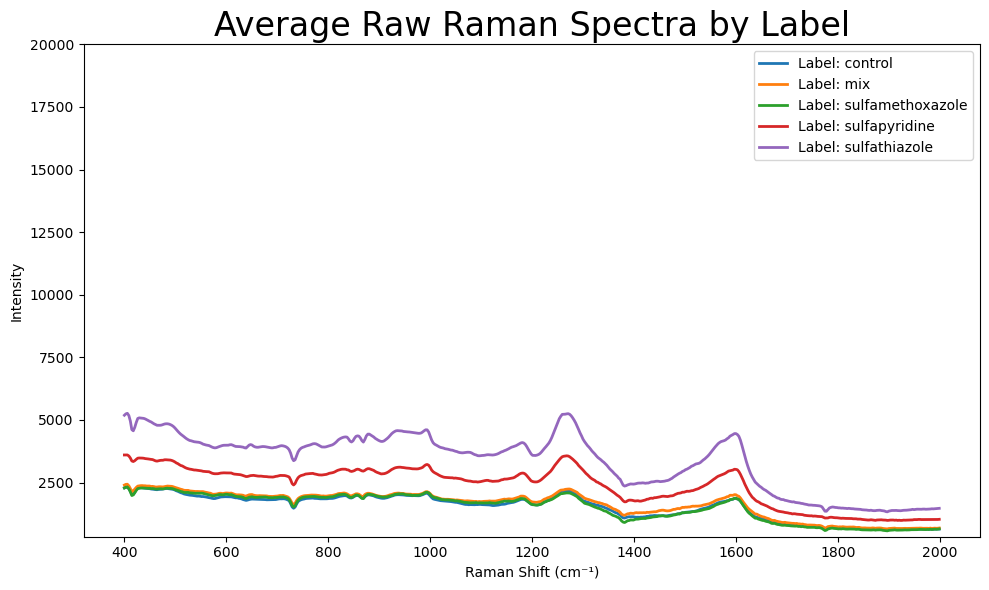

In [10]:
"""
Plot of the raw spectra by label highlighting the average spectrum.
 
"""

# Get all unique labels
unique_labels = np.unique(labels)

# Create a single figure
plt.figure(figsize=(10, 6))

# Plot average spectrum per label
for lbl in unique_labels:
    index = np.where(labels == lbl)[0]
    group_spectra = np.array([raman_spectra[i][1] for i in index])
    mean_spectrum = group_spectra.mean(axis=0)

    # Plot only the average
    plt.plot(wavenumbers, mean_spectrum, linewidth=2, label=f'Label: {lbl}')

# Customize appearance
plt.title('Average Raw Raman Spectra by Label', fontsize=24)
plt.xlabel('Raman Shift (cm⁻¹)')
plt.ylabel('Intensity')
plt.ylim(top=20000)  # Y-axis limit for consistency
plt.legend()
plt.tight_layout()
plt.show()



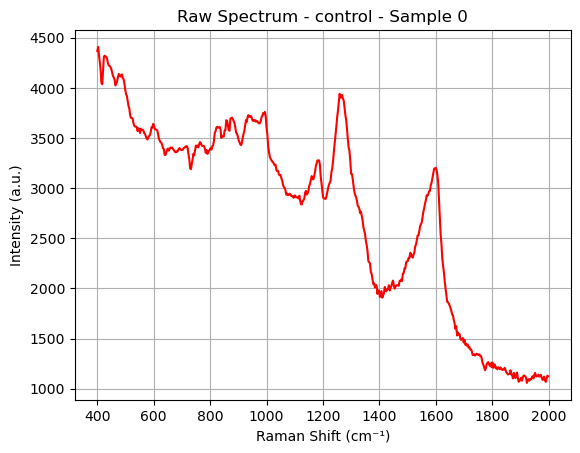

In [4]:
x, y = raman_spectra[0]
plt.plot(x, y, color='red')
plt.title(f"Raw Spectrum - control - Sample 0")
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.grid(True)
plt.show()


In [5]:
def cropper(raman_spectrum, *intervals):
    x = np.array(raman_spectrum[0])
    y = np.array(raman_spectrum[1])

    for interval in intervals:
        min_value, max_value = interval
        indices_to_keep = np.where((x >= min_value) & (x <= max_value))
        x = x[indices_to_keep]
        y = y[indices_to_keep]

    return [x, y]


def whitaker_hayes(raman_spectrum, threshold=6):  #threshold=8
        y_array = raman_spectrum[1]
        median_y = np.median(y_array)
        std_y = np.std(y_array)
        cosmic_rays = np.abs(y_array - median_y) > threshold * std_y
        x_array = raman_spectrum[0]
        x_cosmic = x_array[cosmic_rays]
        f_interp = interp1d(x_array[~cosmic_rays], y_array[~cosmic_rays], kind='quadratic', fill_value='extrapolate') # kind='quadratic'
        y_array[cosmic_rays] = f_interp(x_cosmic)
        return np.array([x_array, y_array])


def denoise_spectrum(raman_spectrum, window_size=15, poly_order=2):# window_size=15, poly_order=2 
        x_array = raman_spectrum[0]
        y_array = raman_spectrum[1]
        window_size = window_size + 1 if window_size % 2 == 0 else window_size
        denoised_y = savgol_filter(y_array, window_size, poly_order)
        return np.array([x_array, denoised_y])


def DRPLS(raman_spectrum, smoothing):
        x_array, y_array = raman_spectrum
        baseline_tuple = drpls(y_array, lam=smoothing, diff_order=2, max_iter=500, tol=0.001, weights=None, x_data=x_array, eta=1.00) #diff_order=2 eta=1.0
        baseline_subtracted_y = y_array - baseline_tuple[0]
        return np.array([x_array, baseline_tuple[0]]), np.array([x_array, baseline_subtracted_y])


def cof_normalize(raman_spectrum): # 1405, 1735
        max_y = None
        for x, y in zip(raman_spectrum[0], raman_spectrum[1]):
            if 1590 <= x <= 1610:
                if max_y is None or y > max_y:
                    max_y = y
        raman_data = raman_spectrum[1] / max_y
        return np.array([raman_spectrum[0], raman_data])


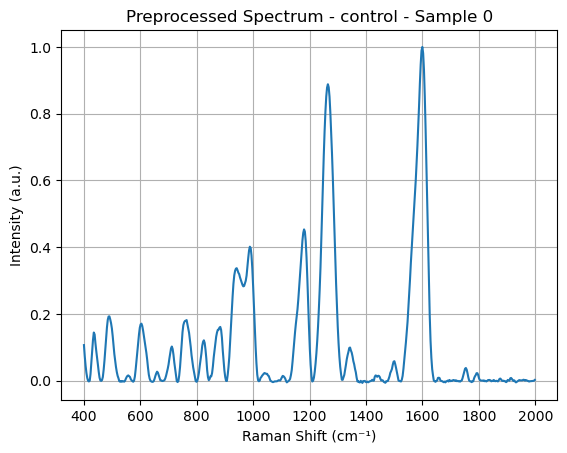

In [6]:
import copy
import numpy as np

# This assumes raman_spectra, metadata, and all preprocessing functions are already defined

processed_spectra = []

# Process all spectra in a loop
for spectrum in raman_spectra:
    lis_spectrum = tuple(arr.tolist() for arr in spectrum)
    original_spectrum = copy.deepcopy(lis_spectrum)

    # Step 1: Crop
    data_crop = cropper(copy.deepcopy(original_spectrum), (300, 2000))

    # Step 2: Cosmic Ray Removal
    data_hay = whitaker_hayes(copy.deepcopy(data_crop))

    # Step 3: Denoising
    data_den = denoise_spectrum(copy.deepcopy(data_hay))

    # Step 4: Smoothing
    _, data_DRP = DRPLS(copy.deepcopy(data_den), 10000)

    # Step 5: Normalization
    data_norm = cof_normalize(copy.deepcopy(data_DRP))

    # Step 6: Final Crop 
    data_crop_f = cropper(copy.deepcopy(data_norm), (400, 2000))
    
    processed_spectra.append(copy.deepcopy(data_crop_f))


first_spectrum = processed_spectra[0]

# Plot it
plt.plot(first_spectrum[0], first_spectrum[1])
plt.title("Preprocessed Spectrum - control - Sample 0")
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.grid(True)
plt.show()

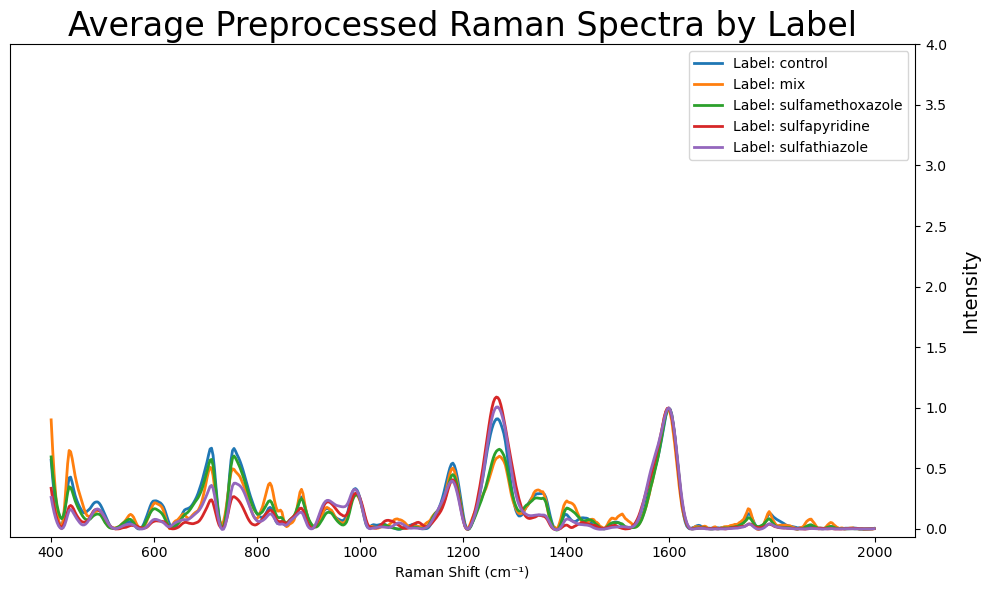

In [18]:
"""
Plot of the preprocessed spectra by label highlighting the average spectrum.
 
"""

# Get all unique labels
unique_labels = np.unique(labels)

# Create a new figure
plt.figure(figsize=(10, 6))

# Plot average spectrum for each label
for lbl in unique_labels:
    index = np.where(labels == lbl)[0]
    group_spectra = np.array([processed_spectra[i][1] for i in index])
    wavenumbers_processed = processed_spectra[0][0]  # x-axis (same for all)
    mean_spectrum = group_spectra.mean(axis=0)
    
    # Plot only the average
    plt.plot(wavenumbers_processed, mean_spectrum, label=f'Label: {lbl}', linewidth=2)

# Customize plot
plt.title('Average Preprocessed Raman Spectra by Label', fontsize= 24)
plt.xlabel('Raman Shift (cm⁻¹)')
plt.ylabel('Intensity', fontsize=14, labelpad=10)
plt.gca().yaxis.set_label_position("right")
plt.gca().yaxis.tick_right()
plt.ylim(top=4)  # Adjust Y-axis if needed
plt.legend()
plt.tight_layout()
plt.show()
